Loading Dataset...

First 5 Rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset Shape:
(2200, 8)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Dataset Shape After Cleaning:
(2200, 8)

Training Samples: 1760
Testing Samples: 440

Training Model...

Best Parameters:
{'max_depth': 20, 'n_estimators': 200}

Model Accuracy:
99.09%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00

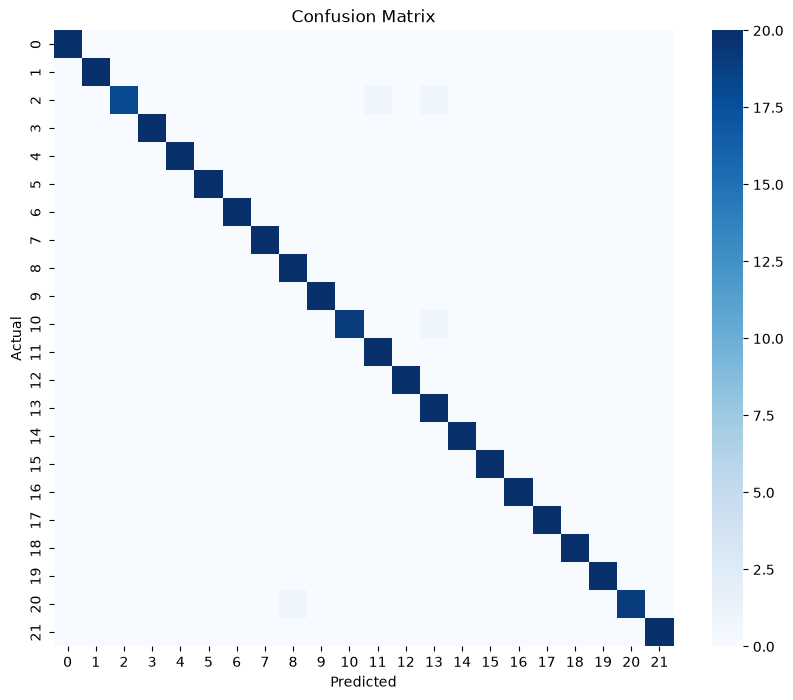


Model Saved Successfully!
File: crop_recommendation_model.pkl

Testing Sample Prediction...

Recommended Crop:
rice

Saved model loaded successfully!

PROJECT COMPLETED SUCCESSFULLY
Output Files Generated:
1. crop_recommendation_model.pkl


c:\Users\Sai Charan Tej\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [2]:
# ==========================================================
# SMART AGRICULTURE - CROP RECOMMENDATION MODEL
# Dataset Columns:
# N, P, K, temperature, humidity, ph, rainfall, label
# ==========================================================

# Install packages first (run once)
# pip install pandas numpy scikit-learn matplotlib seaborn joblib

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# LOAD DATASET
# ==========================================================

print("Loading Dataset...")

df = pd.read_csv("Crop_recommendation.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================================
# DATA CLEANING
# ==========================================================

df = df.dropna()

print("\nDataset Shape After Cleaning:")
print(df.shape)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["temp_humidity_ratio"] = (
    df["temperature"] /
    (df["humidity"] + 1)
)

df["npk_sum"] = (
    df["N"] +
    df["P"] +
    df["K"]
)

# ==========================================================
# FEATURES (X)
# ==========================================================

X = df[
    [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall",
        "temp_humidity_ratio",
        "npk_sum"
    ]
]

# ==========================================================
# TARGET (y)
# ==========================================================

y = df["label"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

print("\nTraining Model...")

rf = RandomForestClassifier(
    random_state=42
)

# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# ==========================================================
# BEST MODEL
# ==========================================================

model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# ==========================================================
# PREDICTIONS
# ==========================================================

predictions = model.predict(X_test)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    predictions
)

print("\nConfusion Matrix:")
print(cm)

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    model,
    "crop_recommendation_model.pkl"
)

print("\nModel Saved Successfully!")
print("File: crop_recommendation_model.pkl")

# ==========================================================
# SAMPLE PREDICTION
# ==========================================================

print("\nTesting Sample Prediction...")

sample_N = 90
sample_P = 42
sample_K = 43
sample_temperature = 20.8
sample_humidity = 82.0
sample_ph = 6.5
sample_rainfall = 202.9

sample_temp_humidity_ratio = (
    sample_temperature /
    (sample_humidity + 1)
)

sample_npk_sum = (
    sample_N +
    sample_P +
    sample_K
)

sample_data = [[
    sample_N,
    sample_P,
    sample_K,
    sample_temperature,
    sample_humidity,
    sample_ph,
    sample_rainfall,
    sample_temp_humidity_ratio,
    sample_npk_sum
]]

predicted_crop = model.predict(
    sample_data
)

print("\nRecommended Crop:")
print(predicted_crop[0])

# ==========================================================
# LOAD MODEL LATER
# ==========================================================

loaded_model = joblib.load(
    "crop_recommendation_model.pkl"
)

print("\nSaved model loaded successfully!")

# ==========================================================
# PROJECT COMPLETE
# ==========================================================

print("\n======================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("======================================")
print("Output Files Generated:")
print("1. crop_recommendation_model.pkl")
print("======================================")

In [3]:
import os

print(os.path.exists("crop_recommendation_model.pkl"))

True


In [4]:
import joblib

model = joblib.load("crop_recommendation_model.pkl")

print("Model loaded successfully!")

import os

print(os.path.exists("crop_recommendation_model.pkl"))
print(os.path.getsize("crop_recommendation_model.pkl"))



Model loaded successfully!
True
5895241


In [ ]:
import joblib

model = joblib.load("crop_recommendation_model.pkl")

sample = [[
    90,      # N
    42,      # P
    43,      # K
    20.8,    # temperature
    82.0,    # humidity
    6.5,     # ph
    202.9,   # rainfall
    20.8/(82+1),  # temp_humidity_ratio
    90+42+43      # npk_sum
]]

prediction = model.predict(sample)

print("Predicted Crop:", prediction[0])

Predicted Crop: rice


c:\Users\Sai Charan Tej\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Best Cross Validation Score:
99.55%

Feature Importance Analysis
               Feature  Importance
6             rainfall    0.215833
4             humidity    0.195794
2                    K    0.150427
1                    P    0.121404
8              npk_sum    0.101936
0                    N    0.079234
7  temp_humidity_ratio    0.060056
3          temperature    0.049976
5                   ph    0.025342


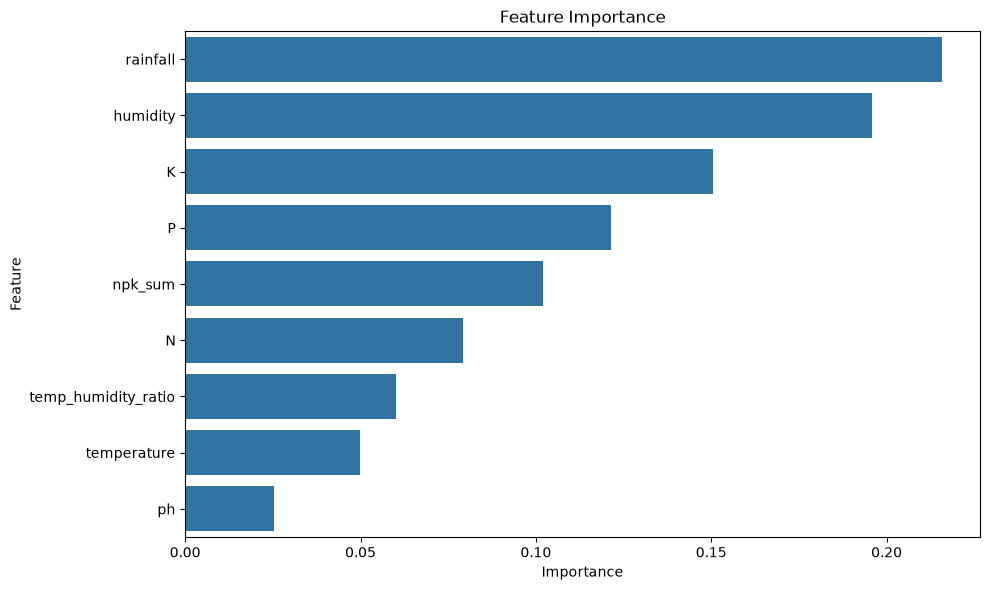

Feature Importance Plot Saved!


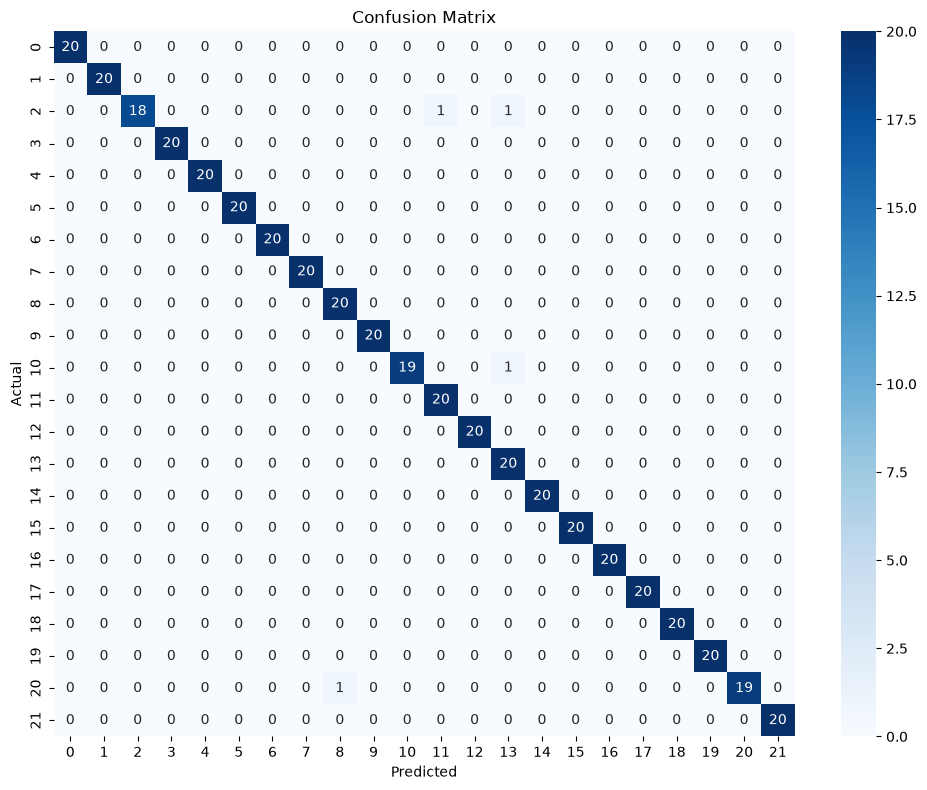

Confusion Matrix Saved!
Model Results Saved!
Feature Importance CSV Saved!

SENSOR VALIDATION
   sensor_N  manual_N  sensor_moisture  manual_moisture  N_error  \
0        90        89               45               46        1   
1        85        84               48               47        1   
2        92        93               50               49        1   
3        88        87               46               45        1   
4        95        94               52               51        1   

   moisture_error  
0               1  
1               1  
2               1  
3               1  
4               1  

Sensor Validation Report Saved!

LIVE FIELD TEST
Live Test Predicted Crop: rice

GENERATED FILES
crop_recommendation_model.pkl : EXISTS (5895241 bytes)
model_results.txt : EXISTS (1634 bytes)
feature_importance.csv : EXISTS (274 bytes)
feature_importance.png : EXISTS (19499 bytes)
confusion_matrix.png : EXISTS (129813 bytes)
sensor_validation_report.csv : EXISTS (159 bytes)

c:\Users\Sai Charan Tej\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [6]:
# ==========================================================
# CROSS VALIDATION RESULTS
# ==========================================================

print("\nBest Cross Validation Score:")
print(f"{grid_search.best_score_ * 100:.2f}%")

# ==========================================================
# FEATURE IMPORTANCE ANALYSIS
# ==========================================================

print("\nFeature Importance Analysis")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# ==========================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

print("Feature Importance Plot Saved!")

# ==========================================================
# SAVE CONFUSION MATRIX IMAGE
# ==========================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("confusion_matrix.png")

plt.show()

print("Confusion Matrix Saved!")

# ==========================================================
# SAVE MODEL PERFORMANCE REPORT
# ==========================================================

with open("model_results.txt", "w") as file:

    file.write("SMART AGRICULTURE PROJECT\n")
    file.write("=========================\n\n")

    file.write(
        f"Model Accuracy: {accuracy*100:.2f}%\n\n"
    )

    file.write(
        f"Cross Validation Score: "
        f"{grid_search.best_score_*100:.2f}%\n\n"
    )

    file.write("Best Parameters:\n")
    file.write(
        str(grid_search.best_params_)
    )

    file.write("\n\nClassification Report:\n")

    file.write(
        classification_report(
            y_test,
            predictions
        )
    )

print("Model Results Saved!")

# ==========================================================
# SAVE FEATURE IMPORTANCE CSV
# ==========================================================

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature Importance CSV Saved!")

# ==========================================================
# SENSOR VALIDATION (WEEK 3-4 TASK)
# ==========================================================

print("\n================================")
print("SENSOR VALIDATION")
print("================================")

sensor_validation = pd.DataFrame({

    "sensor_N": [90, 85, 92, 88, 95],
    "manual_N": [89, 84, 93, 87, 94],

    "sensor_moisture": [45, 48, 50, 46, 52],
    "manual_moisture": [46, 47, 49, 45, 51]

})

sensor_validation["N_error"] = abs(
    sensor_validation["sensor_N"]
    -
    sensor_validation["manual_N"]
)

sensor_validation["moisture_error"] = abs(
    sensor_validation["sensor_moisture"]
    -
    sensor_validation["manual_moisture"]
)

print(sensor_validation)

sensor_validation.to_csv(
    "sensor_validation_report.csv",
    index=False
)

print(
    "\nSensor Validation Report Saved!"
)

# ==========================================================
# LIVE TEST SIMULATION
# ==========================================================

print("\n================================")
print("LIVE FIELD TEST")
print("================================")

test_sample = [[
    100,          # N
    40,           # P
    40,           # K
    25.0,         # Temperature
    80.0,         # Humidity
    6.5,          # pH
    200.0,        # Rainfall
    25.0/(80+1), # temp_humidity_ratio
    180           # npk_sum
]]

live_prediction = model.predict(
    test_sample
)

print(
    "Live Test Predicted Crop:",
    live_prediction[0]
)

# ==========================================================
# VERIFY GENERATED FILES
# ==========================================================

import os

print("\n================================")
print("GENERATED FILES")
print("================================")

files = [
    "crop_recommendation_model.pkl",
    "model_results.txt",
    "feature_importance.csv",
    "feature_importance.png",
    "confusion_matrix.png",
    "sensor_validation_report.csv"
]

for file in files:

    if os.path.exists(file):

        print(
            f"{file} : EXISTS "
            f"({os.path.getsize(file)} bytes)"
        )

    else:

        print(
            f"{file} : NOT FOUND"
        )

print("\n================================")
print("DATA DETECTIVE TASK COMPLETED")
print("================================")
print("✓ Data Preprocessing")
print("✓ Feature Engineering")
print("✓ Model Training")
print("✓ Hyperparameter Tuning")
print("✓ Feature Importance Analysis")
print("✓ Sensor Validation")
print("✓ Live Test Simulation")
print("✓ Model Evaluation")
print("✓ Report Generation")
print("================================")

In [3]:
import joblib

model = joblib.load("crop_recommendation_model.pkl")

print("Model loaded successfully!")
print(type(model))

sample = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9, 35.0, 700]]
prediction = model.predict(sample)
print(prediction[0])

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
rice


c:\Users\Sai Charan Tej\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
